# Демонстрации к лекции 2: выпуклость руками и кодом

Ноутбук читается сверху вниз. Четыре части:

- **(a)** как *проверить* выпуклость функции численно — тест хорды и карта гессиана — и почему это не доказательство;
- **(b)** операции, сохраняющие выпуклость: максимум, композиция — и что ломается, если условие нарушить;
- **(c)** условие оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0$ на задаче с параллелепипедом и на проекции;
- **(d)** выпуклая подгонка (логистическая регрессия) против невыпуклой (нелинейный МНК из лекции 1): что видит численный метод.

Конспект: [`lecture02.md`](lecture02.md). Запуск: `uv run jupyter lab` в корне репозитория.

## 0. Что нового в инструментах

Всё из лекции 1 остаётся (`minimize`, `linprog`, `OptimizeResult`). Сегодня добавляются:

| Что | Зачем |
|---|---|
| `np.linalg.eigvalsh(H)` | собственные числа симметричной матрицы — проверка $H \succeq 0$ |
| `scipy.optimize.approx_fprime(x, f)` | градиент конечными разностями, когда лень выписывать формулу |
| `minimize(..., bounds=[(l, u), ...])` | ограничения $l \le x_i \le u$ — простейшее выпуклое множество; метод `L-BFGS-B` их понимает напрямую |
| `rng.uniform(l, u, size)` | случайные допустимые точки для проверки условий «для всех $y \in \Omega$» |

Соглашение о знаках то же: неравенства $h(x) \ge 0$, максимизация через $\min(-f)$.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import approx_fprime, minimize

BLUE, ORANGE, AQUA, RED, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})
rng = np.random.default_rng(2)

## (a) Проверить выпуклость кодом

Возьмём три функции двух переменных:

| | формула | ожидание |
|---|---|---|
| $f_1$ | $\tfrac12 x^\top Q x$, $Q = \begin{pmatrix} 2 & 0.5 \\ 0.5 & 1\end{pmatrix}$ | выпукла: $Q \succ 0$ |
| $f_2$ | $e^{x_1} + x_2^2 + x_1 x_2$ | ? — сумма выпуклых плюс перекрёстный член |
| $f_3$ | $(x_1^2 - 1)^2 + x_2^2$ | не выпукла: два минимума |

**Тест 1 — хорда.** Определение: $f((1-t)x + ty) \le (1-t)f(x) + tf(y)$. Берём много случайных пар $(x, y)$ и случайных $t$ и ищем нарушение. Одно найденное нарушение — доказательство невыпуклости. Отсутствие нарушений — *не* доказательство выпуклости, а только отсутствие контрпримера в проверенной области.

In [2]:
Q = np.array([[2.0, 0.5], [0.5, 1.0]])
f1 = lambda x: 0.5 * x @ Q @ x
f2 = lambda x: np.exp(x[0]) + x[1] ** 2 + x[0] * x[1]
f3 = lambda x: (x[0] ** 2 - 1) ** 2 + x[1] ** 2

def chord_test(f, n_pairs=20000, box=2.0):
    """Ищет пару точек и t, для которых хорда лежит НИЖЕ графика. Возвращает худшее нарушение."""
    X = rng.uniform(-box, box, (n_pairs, 2)); Y = rng.uniform(-box, box, (n_pairs, 2))
    T = rng.uniform(0, 1, n_pairs)
    worst, arg = 0.0, None
    for x, y, t in zip(X, Y, T):
        gap = f((1 - t) * x + t * y) - ((1 - t) * f(x) + t * f(y))   # > 0  =>  нарушение
        if gap > worst:
            worst, arg = gap, (x, y, t)
    return worst, arg

for name, f in (("f1", f1), ("f2", f2), ("f3", f3)):
    worst, arg = chord_test(f)
    verdict = "нарушений нет" if worst <= 1e-12 else f"НАРУШЕНИЕ: x={arg[0].round(2)}, y={arg[1].round(2)}, t={arg[2]:.2f}, зазор {worst:.3f}"
    print(f"{name}: {verdict}")

f1: нарушений нет
f2: НАРУШЕНИЕ: x=[-1.94  1.63], y=[-0.18  0.77], t=0.39, зазор 0.056
f3: НАРУШЕНИЕ: x=[-0.98 -1.06], y=[ 0.97 -1.4 ], t=0.52, зазор 0.965


**Тест 2 — гессиан на сетке.** Критерий второго порядка: $\nabla^2 f(x) \succeq 0$ во всех точках. Гессиан посчитаем конечными разностями (формулы не нужны), возьмём его наименьшее собственное число $\lambda_{\min}$ и нарисуем карту. Где $\lambda_{\min} < 0$ — там функция точно не выпукла.

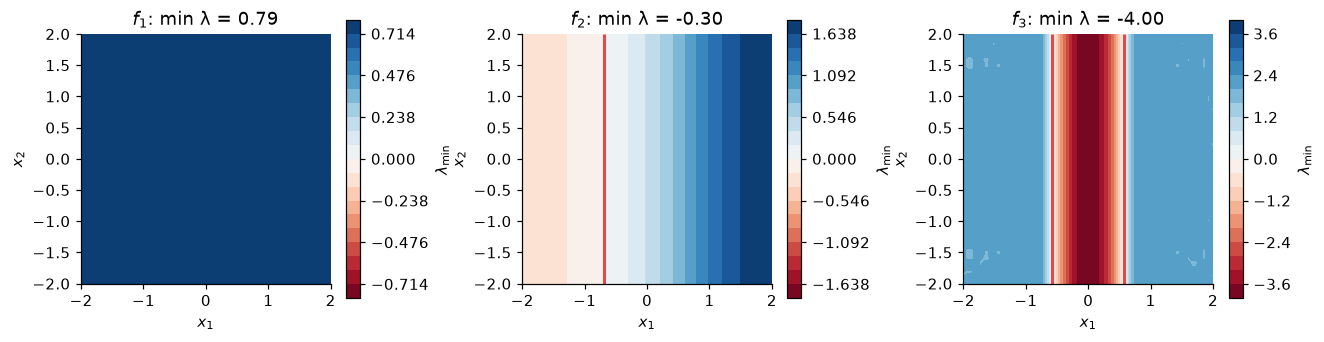

In [3]:
def hess_fd(f, x, eps=1e-4):
    x = np.asarray(x, float); n = x.size; H = np.zeros((n, n)); E = np.eye(n) * eps
    for i in range(n):
        for j in range(n):
            H[i, j] = (f(x + E[i] + E[j]) - f(x + E[i] - E[j]) - f(x - E[i] + E[j]) + f(x - E[i] - E[j])) / (4 * eps**2)
    return 0.5 * (H + H.T)

xs = np.linspace(-2, 2, 61)
X1, X2 = np.meshgrid(xs, xs)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (name, f) in zip(axes, (("$f_1$", f1), ("$f_2$", f2), ("$f_3$", f3))):
    L = np.array([[np.linalg.eigvalsh(hess_fd(f, [a, b]))[0] for a in xs] for b in xs])
    v = np.abs(L).max()
    im = ax.contourf(X1, X2, L, levels=np.linspace(-v, v, 21), cmap="RdBu")
    if (L < 0).any():
        ax.contour(X1, X2, L, levels=[0], colors=[RED], linewidths=2)
    ax.set(title=f"{name}: min λ = {L.min():.2f}", xlabel="$x_1$", ylabel="$x_2$", aspect="equal"); ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8, label="$\\lambda_{\\min}$")
plt.tight_layout(); plt.show()

$f_1$: наименьшее собственное число положительно всюду, контрпримера нет ни у одного теста. $f_3$: красная полоса $|x_1| < 1/\sqrt 3$, там $\lambda_{\min} < 0$ — это уже **доказательство** невыпуклости, одной точки достаточно.

$f_2$ — сюрприз: $e^{x_1}$ и $x_2^2$ выпуклы, но перекрёстный член $x_1 x_2$ всё портит слева. Гессиан $\begin{pmatrix} e^{x_1} & 1 \\ 1 & 2\end{pmatrix}$ положительно определён только при $2e^{x_1} - 1 > 0$, то есть $x_1 > -\log 2 \approx -0.69$. Проверим числами.

In [4]:
for x1 in (-0.5, -0.69, -1.5):
    H = hess_fd(f2, [x1, 0.0])
    print(f"x1 = {x1:5.2f}: собственные числа гессиана f2 = {np.linalg.eigvalsh(H).round(3)}")

x1 = -0.50: собственные числа гессиана f2 = [0.084 2.522]
x1 = -0.69: собственные числа гессиана f2 = [1.0e-03 2.5e+00]
x1 = -1.50: собственные числа гессиана f2 = [-0.226  2.449]


При $x_1 = -1.5$ есть отрицательное собственное число: $f_2$ не выпукла на $\mathbb{R}^2$, хотя на правой половине плоскости выпукла. Два вывода. **Численные тесты умеют только искать контрпример**: для $f_1$ они его не нашли, но доказательство выпуклости — это $Q \succ 0$ (собственные числа $Q$), а не 20 000 удачных пар. **«Сумма выпуклых» — правило, а $x_1 x_2$ в него не входит**: перекрёстный член не выпукл и не вогнут, и его нужно проверять гессианом.

## (b) Операции, сохраняющие выпуклость

Собираем выпуклые функции из кирпичей и смотрим, что получается.

**Максимум аффинных.** $f(x) = \max_i (a_i x + b_i)$ — выпукла (надграфик — пересечение полуплоскостей), но негладка в точках излома. Именно такие функции возникают после slack-переформулировки модуля и максимума.

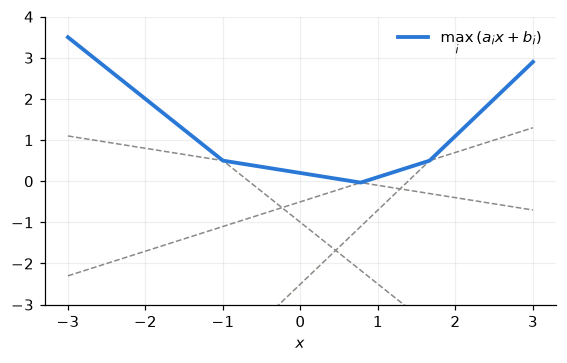

In [5]:
x = np.linspace(-3, 3, 400)
lines = [(-1.5, -1.0), (-0.3, 0.2), (0.6, -0.5), (1.8, -2.5)]
F = np.max([a * x + b for a, b in lines], axis=0)

fig, ax = plt.subplots(figsize=(6, 3.4))
for a, b in lines:
    ax.plot(x, a * x + b, color=GRAY, lw=1, ls="--")
ax.plot(x, F, color=BLUE, lw=2.5, label="$\\max_i (a_i x + b_i)$")
ax.set(ylim=(-3, 4), xlabel="$x$"); ax.legend(); plt.show()

**Композиция с монотонной выпуклой.** Если $f$ выпукла, а $g$ выпукла и **не убывает**, то $g(f(x))$ выпукла. Возьмём $f(x) = x^2 - 1$ (выпукла) и три внешние функции:

| $g(u)$ | выпукла? | не убывает? | $g(f(x))$ |
|---|---|---|---|
| $e^{u}$ | да | да | выпукла |
| $u^2$ | да | **нет** (убывает при $u < 0$) | правило не применимо |
| $-u$ | да (аффинна) | **нет** | правило не применимо |

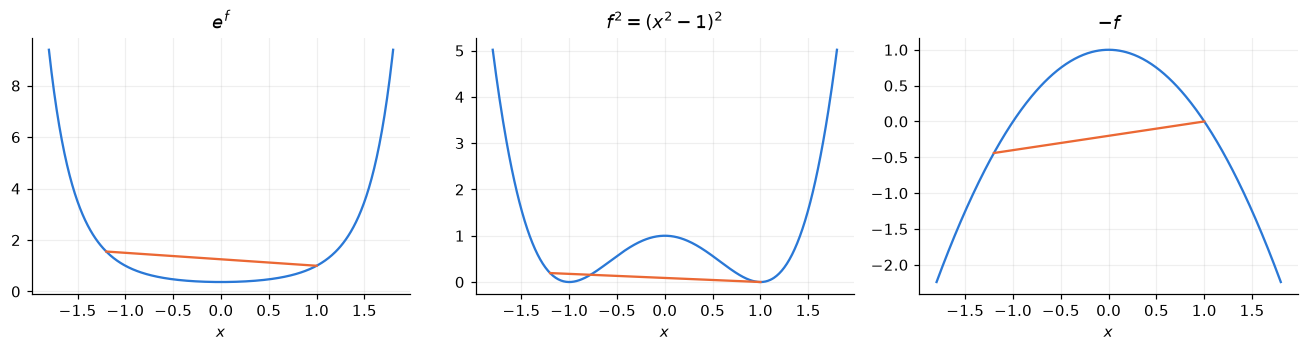

In [6]:
x = np.linspace(-1.8, 1.8, 400)
f = x**2 - 1
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
for ax, (name, g) in zip(axes, (("$e^{f}$", np.exp(f)), ("$f^2 = (x^2-1)^2$", f**2), ("$-f$", -f))):
    ax.plot(x, g, color=BLUE)
    # тест хорды на одной паре точек
    a, b = -1.2, 1.0
    ga, gb = np.interp([a, b], x, g)
    ax.plot([a, b], [ga, gb], color=ORANGE, lw=1.5)
    ax.set(title=name, xlabel="$x$")
plt.tight_layout(); plt.show()

Первая композиция выпукла (хорда над графиком). Вторая — знакомая $(x^2 - 1)^2$: две ямы, хорда под графиком. Третья — перевёрнутая парабола, вогнута. Так что условие «$g$ не убывает» — не формальность: без него композиция выпуклых функций может быть какой угодно.

## (c) Условие оптимальности: $\nabla f(x^\ast)^\top (y - x^\ast) \ge 0$

**Задача.** Квадратичная функция $f(x) = \tfrac12 x^\top Q x + c^\top x$ с $Q \succ 0$ на параллелепипеде $-1 \le x_i \le 1$.

| | |
|---|---|
| переменные | $x \in \mathbb{R}^2$ |
| $f(x)$ | $\tfrac12 x^\top Q x + c^\top x$, $Q = \begin{pmatrix} 2 & 0.5 \\ 0.5 & 1\end{pmatrix}$, $c = (-3, -1)$ |
| $g(x) = 0$ | нет |
| $h(x) \ge 0$ | $1 - x_i \ge 0$, $x_i + 1 \ge 0$ — четыре аффинных неравенства |
| класс | выпуклая QP (цель: $Q \succ 0$; множество: пересечение полупространств) |
| в SciPy | `minimize(f, x0, jac=df, method="L-BFGS-B", bounds=[(-1, 1), (-1, 1)])` |

Безусловный минимум $-Q^{-1}c$ лежит вне параллелепипеда, поэтому решение будет на границе и какие-то ограничения окажутся активными.

In [7]:
c = np.array([-3.0, -1.0])
f = lambda x: 0.5 * x @ Q @ x + c @ x
df = lambda x: Q @ x + c

x_free = -np.linalg.solve(Q, c)
res = minimize(f, x0=np.zeros(2), jac=df, method="L-BFGS-B", bounds=[(-1, 1), (-1, 1)])
x_star = res.x
print("безусловный минимум -Q^{-1}c =", x_free.round(4), " (вне параллелепипеда)")
print("решение с ограничениями x*  =", x_star.round(4), " f* = %.4f" % res.fun)
print("градиент в x*:", df(x_star).round(4), " — НЕ ноль: решение на границе")
print("активные границы:", [f"x{i+1} = {x_star[i]:+.0f}" for i in range(2) if abs(abs(x_star[i]) - 1) < 1e-6])

безусловный минимум -Q^{-1}c = [1.4286 0.2857]  (вне параллелепипеда)
решение с ограничениями x*  = [1.  0.5]  f* = -2.1250
градиент в x*: [-0.75  0.  ]  — НЕ ноль: решение на границе
активные границы: ['x1 = +1']


Градиент в решении не нулевой — и это нормально: решение упёрлось в границу. Проверим условие оптимальности так, как оно сформулировано, — «для всех $y \in \Omega$». Всех перебрать нельзя, возьмём 1000 случайных допустимых $y$ и посмотрим на минимум величины $\nabla f(x^\ast)^\top(y - x^\ast)$. Для контроля проделаем то же в заведомо неоптимальной точке.

In [8]:
Y = rng.uniform(-1, 1, (1000, 2))                     # случайные допустимые точки

def check(x, label):
    vals = (Y - x) @ df(x)
    print(f"{label}: min по y  grad^T (y - x) = {vals.min(): .4f}   ->  {'условие выполнено' if vals.min() >= -1e-8 else 'НАРУШЕНО'}")

check(x_star, "x* = " + str(x_star.round(3)))
check(np.array([0.5, 0.5]), "x  = [0.5 0.5]  ")
check(np.array([1.0, 0.0]), "x  = [1.0 0.0]  ")

x* = [1.  0.5]: min по y  grad^T (y - x) =  0.0075   ->  условие выполнено
x  = [0.5 0.5]  : min по y  grad^T (y - x) = -0.9013   ->  НАРУШЕНО
x  = [1.0 0.0]  : min по y  grad^T (y - x) = -0.4104   ->  НАРУШЕНО


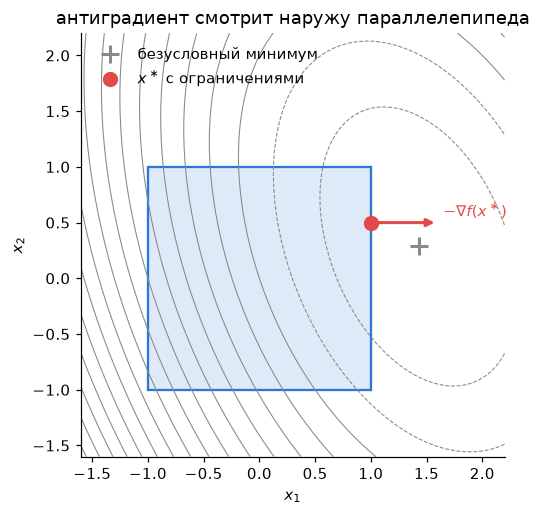

In [9]:
xs = np.linspace(-1.6, 2.2, 200)
X1, X2 = np.meshgrid(xs, xs)
F = 0.5 * (Q[0, 0] * X1**2 + 2 * Q[0, 1] * X1 * X2 + Q[1, 1] * X2**2) + c[0] * X1 + c[1] * X2

fig, ax = plt.subplots(figsize=(5.4, 5))
ax.contour(X1, X2, F, levels=20, colors=[GRAY], linewidths=0.7)
ax.add_patch(plt.Rectangle((-1, -1), 2, 2, color=BLUE, alpha=0.15, lw=0))
ax.add_patch(plt.Rectangle((-1, -1), 2, 2, fill=False, color=BLUE, lw=1.5))
ax.plot(*x_free, "+", color=GRAY, ms=12, mew=2, label="безусловный минимум")
ax.plot(*x_star, "o", color=RED, ms=9, label="$x^\\ast$ с ограничениями")
g = -df(x_star); g = 0.6 * g / np.linalg.norm(g)
ax.annotate("", xy=x_star + g, xytext=x_star, arrowprops=dict(arrowstyle="-|>", color=RED, lw=2))
ax.text(*(x_star + g + [0.05, 0.05]), "$-\\nabla f(x^\\ast)$", color=RED)
ax.set(aspect="equal", xlabel="$x_1$", ylabel="$x_2$", title="антиградиент смотрит наружу параллелепипеда")
ax.legend(loc="upper left"); ax.grid(False); plt.show()

**Проекция на шар.** Второй пример из раздела 7 конспекта: $\min \tfrac12\Vert x - p\Vert^2$ при $\Vert x\Vert \le 1$. Формула $x^\ast = p/\Vert p\Vert$ (если $\Vert p\Vert > 1$) против `minimize`.

In [10]:
p = np.array([2.0, 1.5])
res = minimize(lambda x: 0.5 * np.sum((x - p) ** 2), x0=np.zeros(2), method="SLSQP",
               constraints=[{"type": "ineq", "fun": lambda x: 1 - x @ x}])
print("minimize:", res.x.round(6), "   формула p/|p|:", (p / np.linalg.norm(p)).round(6))
print("условие (x* - p)^T (y - x*) >= 0 на случайных y из шара:",
      end=" ")
Yb = rng.normal(size=(2000, 2)); Yb = Yb / np.maximum(1, np.linalg.norm(Yb, axis=1, keepdims=True))   # точки в шаре
print(f"min = {((Yb - res.x) @ (res.x - p)).min(): .5f}")

minimize: [0.8 0.6]    формула p/|p|: [0.8 0.6]
условие (x* - p)^T (y - x*) >= 0 на случайных y из шара: min =  0.00001


## (d) Выпуклая подгонка против невыпуклой

**Логистическая регрессия.** Есть точки $a_i \in \mathbb{R}^2$ двух классов $y_i \in \{-1, +1\}$; ищем разделяющую прямую $w^\top a + b = 0$. Обучение — минимизация потери

$$
f(w, b) = \sum_{i=1}^N \log\big(1 + e^{-y_i (w^\top a_i + b)}\big) + \tfrac{\lambda}{2}\Vert w\Vert^2 .
$$

| | |
|---|---|
| переменные | $x = (w, b) \in \mathbb{R}^3$ |
| $f(x)$ | сумма выпуклых $\log(1 + e^{u})$ от аффинных $u_i(x)$ плюс квадрат нормы |
| ограничения | нет |
| класс | **выпуклая** безусловная NLP (при $\lambda > 0$ — строго выпуклая) |

Запустим BFGS из 10 случайных стартов.

In [11]:
N = 200
A = np.vstack([rng.normal([-1.5, -1.0], 1.0, (N // 2, 2)), rng.normal([1.5, 1.0], 1.0, (N // 2, 2))])
y = np.r_[-np.ones(N // 2), np.ones(N // 2)]
lam = 0.01

def logloss(x):
    u = -y * (A @ x[:2] + x[2])
    return np.sum(np.logaddexp(0, u)) + 0.5 * lam * x[:2] @ x[:2]

def dlogloss(x):
    u = -y * (A @ x[:2] + x[2])
    s = -y / (1 + np.exp(-u))                      # d/du log(1+e^u) * du/dx
    return np.r_[A.T @ s + lam * x[:2], s.sum()]

starts = rng.uniform(-5, 5, (10, 3))
sols = np.array([minimize(logloss, x0, jac=dlogloss, method="BFGS").x for x0 in starts])
print("решения из 10 стартов (w1, w2, b):")
print(sols.round(4))
print("разброс между решениями:", np.ptp(sols, axis=0).round(6), " -> одна и та же точка")

решения из 10 стартов (w1, w2, b):
[[2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]
 [2.9808 1.2677 0.3104]]
разброс между решениями: [3.e-06 2.e-06 3.e-06]  -> одна и та же точка


**Нелинейный МНК** из упражнения 12.1(г) лекции 1: подогнать $x_1 e^{-x_2 t}$ к данным. Задача невыпукла (на плато гессиан индефинитен). Те же 10 стартов, но уже в $\mathbb{R}^2$.

In [12]:
t = np.linspace(0, 3, 25)
yd = 2.0 * np.exp(-1.5 * t) + 0.05 * rng.normal(size=t.size)
r = lambda x: x[0] * np.exp(-x[1] * t) - yd
fnl = lambda x: 0.5 * np.sum(r(x) ** 2)

starts2 = rng.uniform(-5, 5, (10, 2))
import warnings
with np.errstate(over="ignore", invalid="ignore"), warnings.catch_warnings():   # при x2 < 0 экспонента переполняется — это часть истории
    warnings.simplefilter("ignore")
    res2 = [minimize(fnl, x0, method="BFGS") for x0 in starts2]
print(" старт           ->  решение             f        success")
for x0, rr in zip(starts2, res2):
    print(f"{x0.round(2)!s:16s} -> {rr.x.round(3)!s:20s} {rr.fun:9.4f}   {rr.success}")

 старт           ->  решение             f        success
[3.43 2.98]      -> [1.971 1.524]           0.0204   True
[-0.9   0.19]    -> [1.971 1.524]           0.0204   True
[-2.15 -0.91]    -> [1.971 1.524]           0.0204   True
[1.07 0.35]      -> [1.971 1.524]           0.0204   True
[-0.08 -0.32]    -> [1.971 1.524]           0.0204   True
[-0.32 -4.98]    -> [1.971 1.524]           0.0204   True
[-0.46  1.88]    -> [1.971 1.524]           0.0204   True
[-3.54 -3.86]    -> [-3.442 -2.859]      327385160.4878   False
[-3.97 -4.93]    -> [-3.884 -3.924]      202628448739.5837   False
[-2.87 -4.3 ]    -> [-2.754 -3.295]      2610824826.8217   False


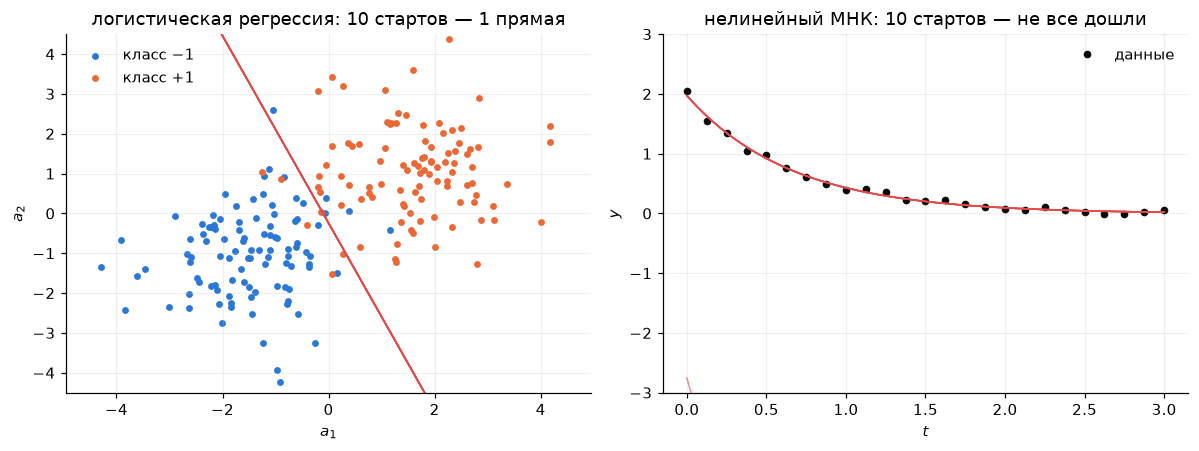

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.scatter(*A[y < 0].T, s=12, color=BLUE, label="класс −1")
ax.scatter(*A[y > 0].T, s=12, color=ORANGE, label="класс +1")
xx = np.linspace(-4.5, 4.5, 50)
for w1, w2, b in sols:
    ax.plot(xx, -(w1 * xx + b) / w2, color=RED, lw=1, alpha=0.6)
ax.set(title="логистическая регрессия: 10 стартов — 1 прямая", xlabel="$a_1$", ylabel="$a_2$", ylim=(-4.5, 4.5))
ax.legend(loc="upper left")

ax = axes[1]
tt = np.linspace(0, 3, 200)
ax.plot(t, yd, "o", color=INK, ms=4, label="данные")
for rr in res2:
    ax.plot(tt, rr.x[0] * np.exp(-rr.x[1] * tt), color=RED, lw=1, alpha=0.6)
ax.set(title="нелинейный МНК: 10 стартов — не все дошли", xlabel="$t$", ylabel="$y$", ylim=(-3, 3))
ax.legend()
plt.tight_layout(); plt.show()

Слева все десять прямых слились в одну: задача выпукла, и старт влиял только на число итераций. Справа семь запусков нашли правильную кривую, а три, стартовавшие с $x_2 < 0$, ушли в область, где экспонента растёт: значение $f$ взорвалось, `success=False`, кривые вылетают из графика. Метод один и тот же — BFGS; разница только в выпуклости задачи.

## Шпаргалка

| Вопрос | Как проверить | Инструмент |
|---|---|---|
| множество выпукло? | пересечение полупространств / шаров / аффинных множеств → да; нелинейное равенство или объединение → скорее нет; сомневаетесь — найдите отрезок | рисунок; `segment`-тест из `make_figures.py` |
| функция выпукла? | квадратичная: $Q \succeq 0$; гладкая: $\nabla^2 f \succeq 0$ всюду; составная: операции раздела 5 | `np.linalg.eigvalsh`, `hess_fd` на сетке (только для поиска контрпримера) |
| задача выпукла? | $f$ выпукла, равенства аффинны, $h_i$ вогнуты | чек-лист раздела 6 конспекта |
| точка — решение? | $\nabla f(x^\ast)^\top (y - x^\ast) \ge 0$ на допустимых $y$; без ограничений $\nabla f = 0$ | `approx_fprime`, случайные $y$ |
| простые ограничения $l \le x \le u$ | `bounds=` + `method="L-BFGS-B"` | `minimize` |

Три типичные ошибки:

1. **«Тест не нашёл контрпример, значит, выпукла».** Нет: тест хорды и карта гессиана могут доказать только *не*выпуклость. Выпуклость доказывается критерием или сборкой из операций.
2. **Композиция без монотонности.** $(x^2 - 1)^2$ — композиция двух выпуклых функций, но внешняя не монотонна, и результат не выпукл.
3. **Нелинейное равенство.** $\Vert x\Vert^2 = 1$ ломает выпуклость всегда, даже если цель прекрасна; $\Vert x\Vert^2 \le 1$ — нет.